In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Distance restraint potential function
def V_dr_array(r_ij, r0, r1, r2, k_dr):
    r_ij = np.asarray(r_ij)
    V = np.zeros_like(r_ij)

    cond1 = r_ij < r0
    cond2 = (r_ij >= r0) & (r_ij < r1)
    cond3 = (r_ij >= r1) & (r_ij < r2)
    cond4 = r_ij >= r2

    V[cond1] = 0.5 * k_dr * (r_ij[cond1] - r0)**2
    V[cond2] = 0
    V[cond3] = 0.5 * k_dr * (r_ij[cond3] - r1)**2
    V[cond4] = 0.5 * k_dr * (r2 - r1) * (2*r_ij[cond4] - r2 - r1)

    return V

# Plotting function
def plot_V_dr(ax, r0, r1, r2, k_dr, label=None, color=None):
    r_values = np.linspace(0, 5, 50)
    V_values = V_dr_array(r_values, r0, r1, r2, k_dr)
    ax.plot(r_values, V_values, label=label, linewidth=2, color=color)


# Dihedral potential function (periodic type), using radians
def V_d(phi_rad, k_phi, n, phi_s_rad):
    return k_phi * (1 + np.cos(n * phi_rad - phi_s_rad))


/var/folders/tx/wwsd51jj247d8523pg4bttp80000gr/T/ipykernel_44679/3953370320.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('cool', len(lambdas))


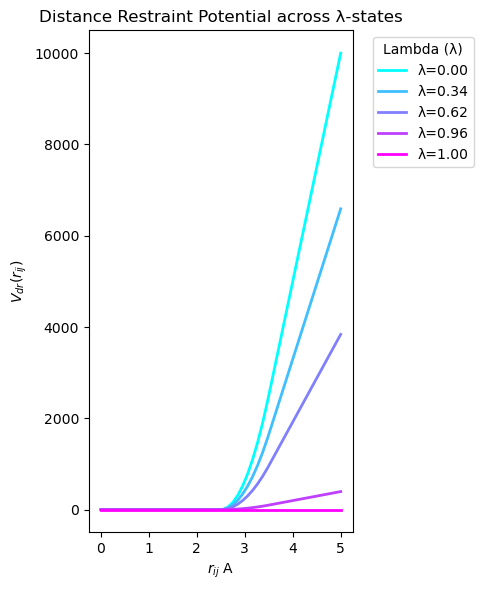

In [3]:

# Input values
r0, r1, r2 = 0.00, 2.5, 3.5
k_max = 5000

# Lambda values from fep-lambdas line
lambdas = [
    0.00000, 0.34107,0.61612, 0.96051,1.00000
]

# Colors from the "cool" colormap
colormap = cm.get_cmap('cool', len(lambdas))

# Plotting
fig, ax = plt.subplots(figsize=(5, 6))
for i, lam in enumerate(lambdas):
    k_dr = (1 - lam) * k_max  # linear interpolation
    color = colormap(i)
    plot_V_dr(ax, r0, r1, r2, k_dr, label=f'λ={lam:.2f}', color=color)

# Final plot settings
ax.set_title("Distance Restraint Potential across λ-states")
ax.set_xlabel('$r_{ij}$ A')
ax.set_ylabel('$V_{dr}(r_{ij})$')
#ax.grid(True)
ax.legend(title='Lambda (λ)', bbox_to_anchor=(1.05, 1), loc='best')
plt.tight_layout()
plt.show()


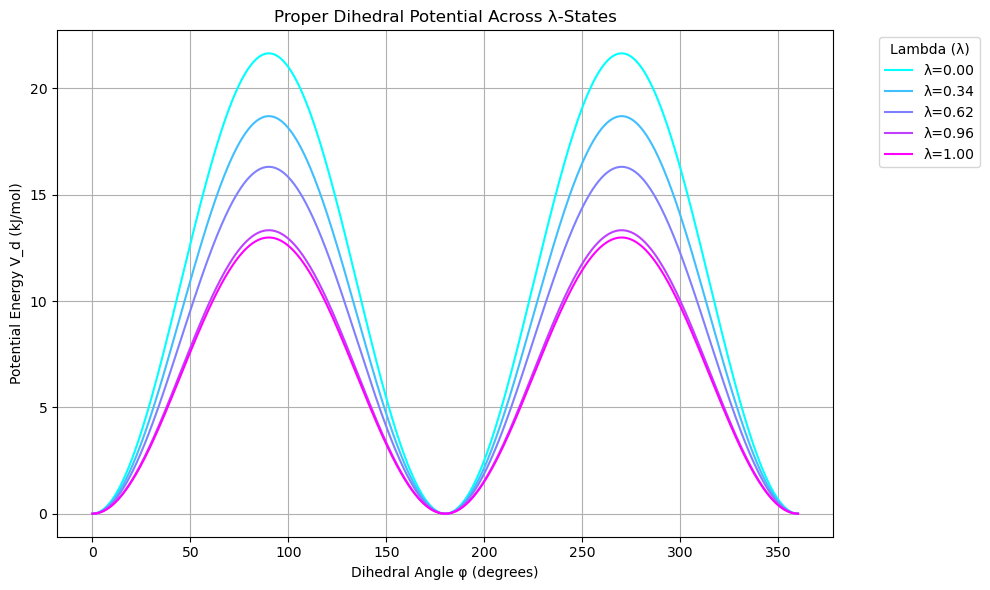

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Dihedral potential function (periodic type), using radians
def V_d(phi_rad, k_phi, n, phi_s_rad):
    return k_phi * (1 + np.cos(n * phi_rad - phi_s_rad))

# 16 lambda values (only 5 shown here)
# lambdas = [  0.00000, 0.34107, 0.61612, 0.96051, 1.00000 ]
lambdas = [ 0.00, 0.34, 0.62, 0.96, 1.00 ]

# Parameters (in radians)
phi_s_deg = 180
phi_s_rad = np.radians(phi_s_deg)  # Convert to radians
n = 2
k_phi_max = 10.82505  # lambda = 0
k_phi_min = 6.49503   # lambda = 1

# Dihedral angle values (0 to 2π in radians)
phi_vals_rad = np.linspace(0, 2 * np.pi, 500)

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))
colormap = cm.get_cmap('cool', len(lambdas))

# Plot each lambda state's potential
for i, lam in enumerate(lambdas):
    k_phi = k_phi_min + (1 - lam) * (k_phi_max - k_phi_min)
    V_vals = V_d(phi_vals_rad, k_phi, n, phi_s_rad)
    ax.plot(np.degrees(phi_vals_rad), V_vals, label=f'λ={lam:.2f}', color=colormap(i))

# Styling
ax.set_title("Proper Dihedral Potential Across λ-States")
ax.set_xlabel("Dihedral Angle φ (degrees)")
ax.set_ylabel("Potential Energy V_d (kJ/mol)")
ax.legend(title="Lambda (λ)", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)

plt.tight_layout()
plt.show()


/var/folders/tx/wwsd51jj247d8523pg4bttp80000gr/T/ipykernel_44679/3684939123.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('cool', len(lambdas))


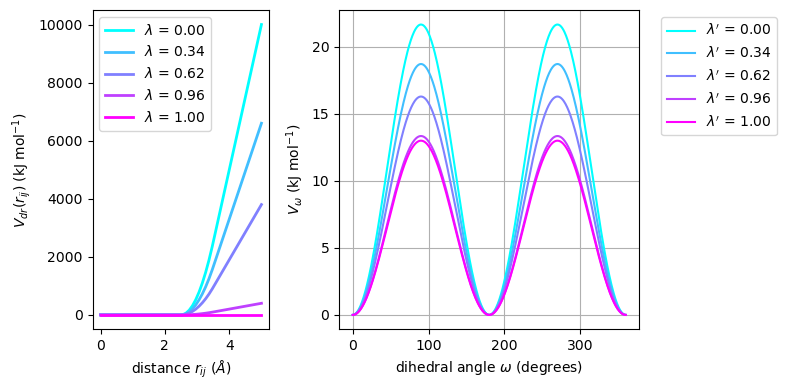

In [31]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 4))
colormap = cm.get_cmap('cool', len(lambdas))

gs = gridspec.GridSpec(1, 5)  # 1 row, 3 columns

ax1 = fig.add_subplot(gs[0, 0:2])      # First tile (1/3)
if (1):
    for i, lam in enumerate(lambdas):
        k_dr = (1 - lam) * k_max  # linear interpolation
        color = colormap(i)
        plot_V_dr(ax1, r0, r1, r2, k_dr, label=(r"$\lambda $ = " + f'{lam:.2f}'), color=color)
    
    # Final plot settings
    # ax1.set_title("Distance restraints")
    ax1.set_xlabel(r'distance $r_{ij}$ ($\AA$)')
    ax1.set_ylabel(r'$V_{dr}(r_{ij})$ (kJ mol$^{-1}$)')
    #ax.grid(True)
    # ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.legend(loc='best')

ax2 = fig.add_subplot(gs[0:1, 2:5])   # Span the next two tiles (2/3)
if (1):
    # 16 lambda values (only 5 shown here)
    # lambdas = [  0.00000, 0.34107, 0.61612, 0.96051, 1.00000 ]
    lambdas = [ 0.00, 0.34, 0.62, 0.96, 1.00 ]
    
    # Parameters (in radians)
    phi_s_deg = 180
    phi_s_rad = np.radians(phi_s_deg)  # Convert to radians
    n = 2
    k_phi_max = 10.82505  # lambda = 0
    k_phi_min = 6.49503   # lambda = 1
    
    # Dihedral angle values (0 to 2π in radians)
    phi_vals_rad = np.linspace(0, 2 * np.pi, 500)
    
    # Plot each lambda state's potential
    for i, lam in enumerate(lambdas):
        k_phi = k_phi_min + (1 - lam) * (k_phi_max - k_phi_min)
        V_vals = V_d(phi_vals_rad, k_phi, n, phi_s_rad)
        ax2.plot(np.degrees(phi_vals_rad), V_vals, label=(r"$\lambda '$ = " + f'{lam:.2f}'), color=colormap(i))
    
    # Styling
    # ax2.set_title("Proper Dihedral Potentials")
    ax2.set_xlabel(r"dihedral angle $\omega$ (degrees)")
    ax2.set_ylabel(r"$V_{\omega}$ (kJ mol$^{-1}$)")
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True)

plt.tight_layout()

plt.savefig('restraint_potentials_v2.pdf')
plt.show()
